In [1]:
# ML

#import data set

!pip install medmnist

In [2]:
import medmnist
print(medmnist.__version__)

3.0.2


In [3]:
from medmnist import DermaMNIST
train_dataset = DermaMNIST(split="train", download=True)

In [4]:
from medmnist import DermaMNIST
test_dataset = DermaMNIST(split="test", download=True)

In [5]:
# List all available dataset
from medmnist import DermaMNIST
from medmnist import INFO

# Load the dataset
data_flag = 'dermamnist'
download = True
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])
dataset = DataClass(split='train', download=download)


In [6]:
from medmnist import DermaMNIST
val_dataset = DermaMNIST(split="val", download=True)

In [7]:
from medmnist import DermaMNIST

# Load training, testing, and validation datasets
train_dataset = DermaMNIST(split="train", download=True)
test_dataset = DermaMNIST(split="test", download=True)
val_dataset = DermaMNIST(split="val", download=True)


In [8]:
import numpy as np

# Save the images and labels
images = dataset.imgs
labels = dataset.labels

np.save('dermamnist_images.npy', images)
np.save('dermamnist_labels.npy', labels)


In [9]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO, Evaluator

In [10]:
import medmnist
print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")


MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/


# We first work on a 2D dataset with size 28x28

In [11]:
data_flag = 'dermamnist'
download = True

# Class labels
classes = [
    'Actinic Keratosis',
    'Basal Cell Carcinoma',
    'Benign Keratosis',
    'Dermatofibroma',
    'Melanoma',
    'Melanocytic Nevus',
    'Vascular Lesion'
]

NUM_EPOCHS = 3
BATCH_SIZE = 128
lr = 0.001
info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])
DataClass = getattr(medmnist, info['python_class'])



In [12]:
# Preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])
# Load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
#Encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=2*BATCH_SIZE, shuffle=False)


In [13]:
print(train_dataset)
print("===================")
print(test_dataset)

Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 7007
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
    Number of samples: {'train': 7007, 'val': 1003, 'test': 2005}
    Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
    License: CC BY-NC 4.0
Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 200

In [14]:
# visualization

train_dataset.montage(length=1)

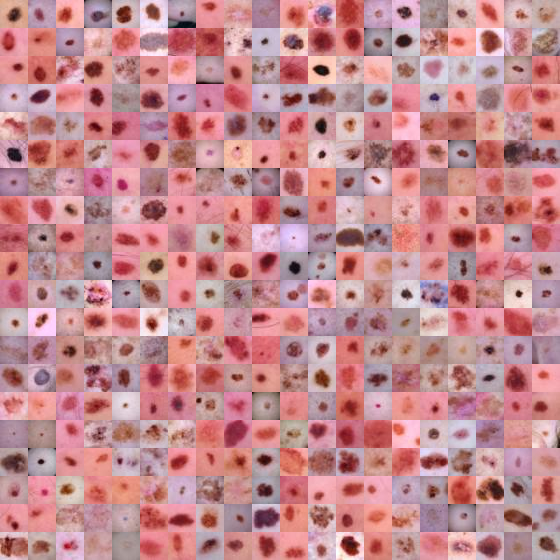

In [15]:
# montage

train_dataset.montage(length=20)

EDA

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from medmnist import DermaMNIST, INFO
from torchvision import transforms
import warnings
warnings.filterwarnings('ignore')

In [17]:
# 1. Class Distribution Analysis
def plot_class_distribution(labels, split, filename):
    unique, counts = np.unique(labels.ravel(), return_counts=True)
    support = counts[np.argsort(unique)]
    plt.figure(figsize=(10, 6))
    bars = plt.bar(classes, support, color='skyblue', edgecolor='black')
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}',
                 ha='center', va='bottom', fontsize=10)
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.title(f'Class Distribution in DermaMNIST {split} Set', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    # plt.savefig(filename)
    # plt.close()
    return support




Class Distribution Summary:
Class                     Train      Val        Test      
Actinic Keratosis         228        33         66        
Basal Cell Carcinoma      359        52         103       
Benign Keratosis          769        110        220       
Dermatofibroma            80         12         23        
Melanoma                  779        111        223       
Melanocytic Nevus         4693       671        1341      
Vascular Lesion           99         14         29        

Gini Index (Imbalance Metric):
Training Set: 0.523
Validation Set: 0.524
Test Set: 0.524


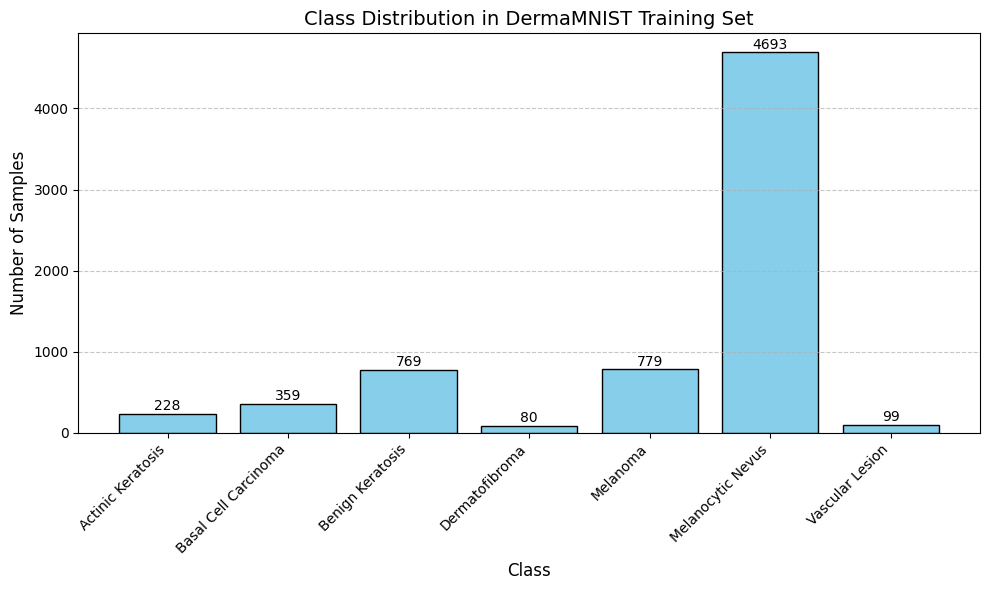

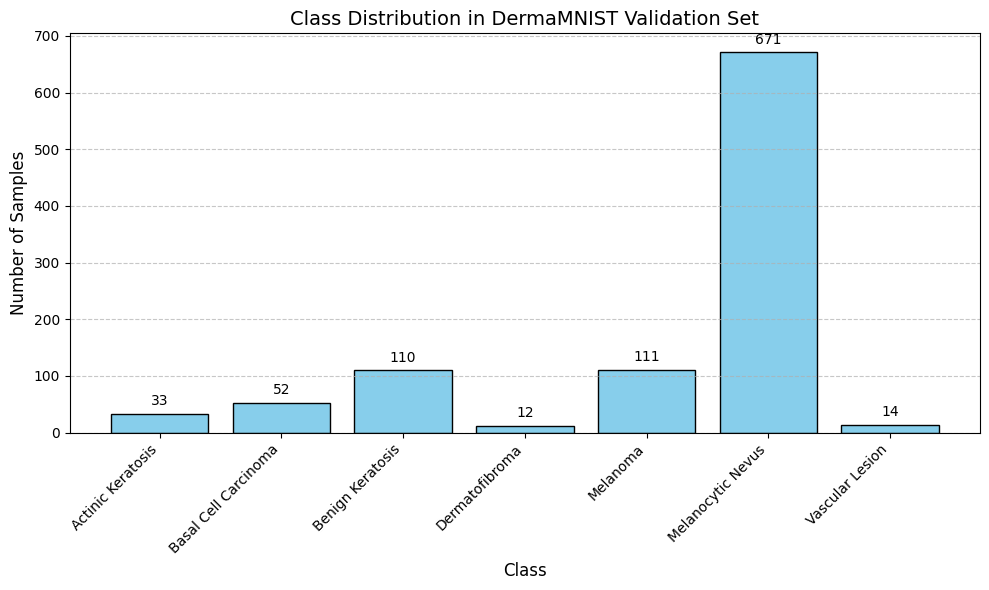

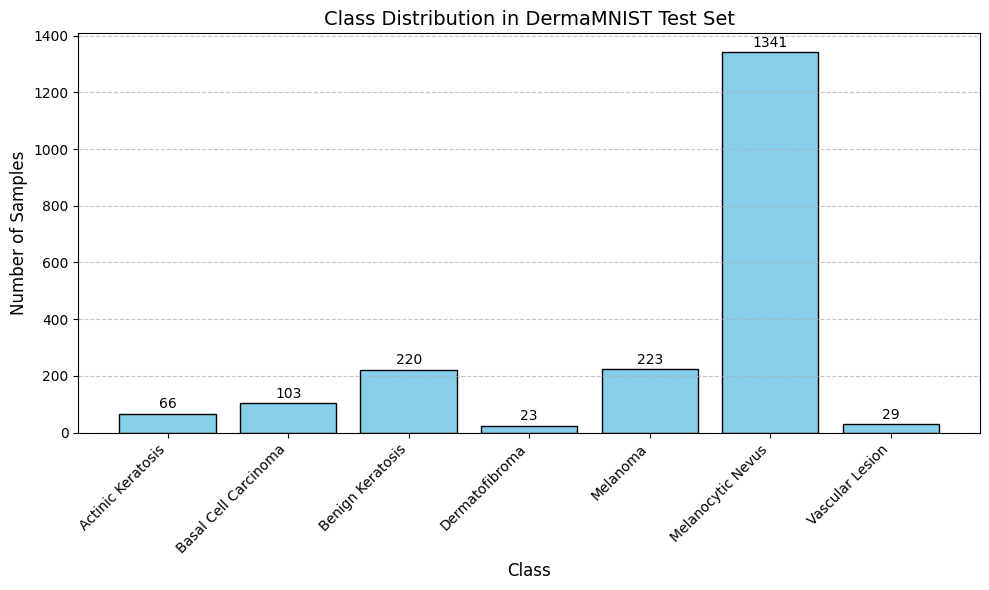

In [18]:
# Plot class distributions
train_support = plot_class_distribution(train_dataset.labels, 'Training', 'class_distribution_train.png')
val_support = plot_class_distribution(val_dataset.labels, 'Validation', 'class_distribution_val.png')
test_support = plot_class_distribution(test_dataset.labels, 'Test', 'class_distribution_test.png')

# Print class distribution summary
print("\nClass Distribution Summary:")
print(f"{'Class':<25} {'Train':<10} {'Val':<10} {'Test':<10}")
for i, cls in enumerate(classes):
    print(f"{cls:<25} {train_support[i]:<10} {val_support[i]:<10} {test_support[i]:<10}")

# Calculate Gini index for imbalance
def gini_index(support):
    proportions = support / np.sum(support)
    return 1 - np.sum(proportions**2)

print(f"\nGini Index (Imbalance Metric):")
print(f"Training Set: {gini_index(train_support):.3f}")
print(f"Validation Set: {gini_index(val_support):.3f}")
print(f"Test Set: {gini_index(test_support):.3f}")



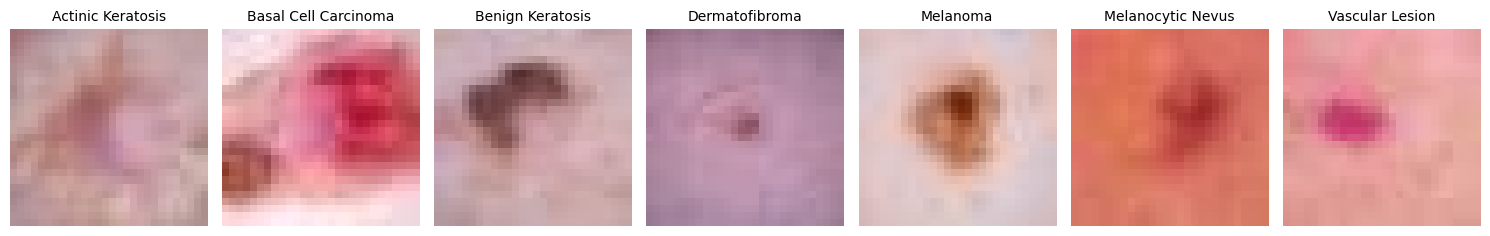

In [19]:
# 2. Visualize Sample Images
def plot_sample_images(dataset, filename):
    plt.figure(figsize=(15, 5))
    for i in range(n_classes):
        # Find first image of each class
        idx = np.where(dataset.labels.ravel() == i)[0][0]
        img = dataset.imgs[idx]  # Shape: (28, 28, 3)
        plt.subplot(1, n_classes, i+1)
        plt.imshow(img)
        plt.title(classes[i], fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    # plt.savefig(filename)
    # plt.close()

plot_sample_images(train_dataset, 'sample_images.png')



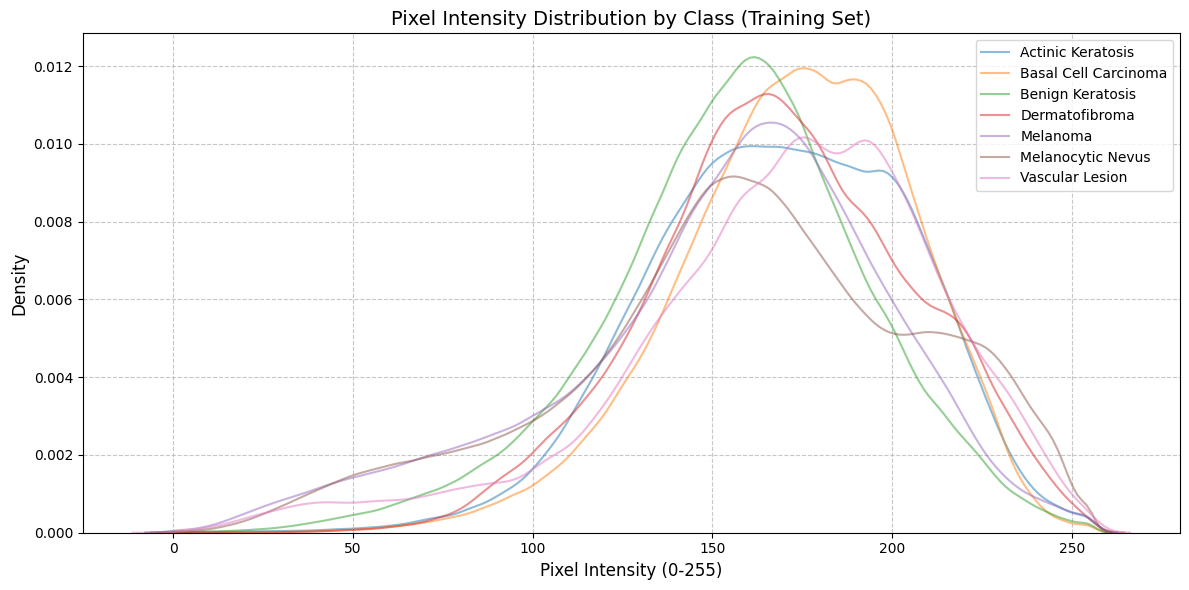

In [20]:
# 3. Pixel Intensity Distribution
def plot_pixel_intensity(dataset, filename):
    pixel_values = []
    for i in range(n_classes):
        class_indices = np.where(dataset.labels.ravel() == i)[0]
        class_images = dataset.imgs[class_indices]  # Shape: (n_samples, 28, 28, 3)
        pixel_values.append(class_images.flatten())

    plt.figure(figsize=(12, 6))
    for i, pixels in enumerate(pixel_values):
        sns.kdeplot(pixels, label=classes[i], alpha=0.5)
    plt.xlabel('Pixel Intensity (0-255)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title('Pixel Intensity Distribution by Class (Training Set)', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    # plt.savefig(filename)
    # plt.close()

plot_pixel_intensity(train_dataset, 'pixel_intensity_distribution.png')



In [21]:
# 4. Image Statistics (Mean and Std per Class)
def compute_image_stats(dataset):
    stats = []
    for i in range(n_classes):
        class_indices = np.where(dataset.labels.ravel() == i)[0]
        class_images = dataset.imgs[class_indices]  # Shape: (n_samples, 28, 28, 3)
        mean = np.mean(class_images, axis=(0, 1, 2))  # Mean across height, width, channels
        std = np.std(class_images, axis=(0, 1, 2))    # Std across height, width, channels
        stats.append((mean, std))
    return stats

train_stats = compute_image_stats(train_dataset)
print("\nImage Statistics (Mean and Std per Class, Training Set):")
print(f"{'Class':<25} {'Mean (R,G,B)':<20} {'Std (R,G,B)':<20}")
for i, (mean, std) in enumerate(train_stats):
    mean_str = f"({mean[0]:.2f}, {mean[1]:.2f}, {mean[2]:.2f})"
    std_str = f"({std[0]:.2f}, {std[1]:.2f}, {std[2]:.2f})"
    print(f"{classes[i]:<25} {mean_str:<20} {std_str:<20}")


Image Statistics (Mean and Std per Class, Training Set):
Class                     Mean (R,G,B)         Std (R,G,B)         
Actinic Keratosis         (200.28, 149.73, 155.88) (23.52, 28.06, 31.00)
Basal Cell Carcinoma      (198.05, 156.59, 163.60) (23.25, 28.04, 30.34)
Benign Keratosis          (180.38, 140.02, 147.24) (30.61, 31.72, 35.30)
Dermatofibroma            (199.36, 148.73, 157.65) (25.72, 28.71, 31.61)
Melanoma                  (178.32, 136.47, 142.83) (37.71, 42.16, 46.54)
Melanocytic Nevus         (198.93, 134.40, 139.72) (34.88, 40.64, 44.57)
Vascular Lesion           (197.84, 146.23, 161.58) (35.99, 41.89, 37.95)


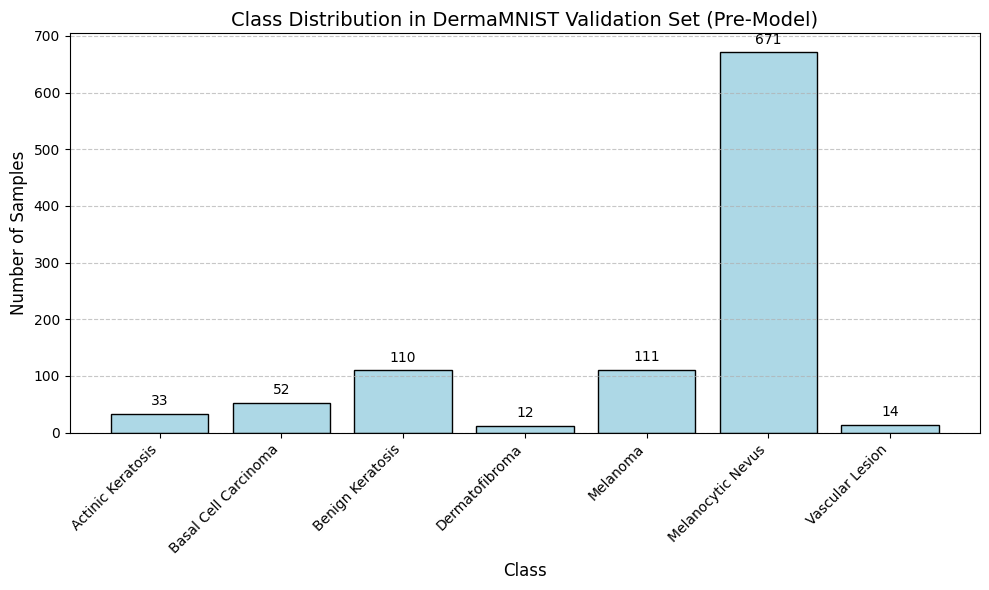

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from medmnist import DermaMNIST
from torchvision import transforms

# Configuration for DermaMNIST dataset
data_flag = 'dermamnist'
download = True

# Class labels for DermaMNIST
classes = [
    'Actinic Keratosis',
    'Basal Cell Carcinoma',
    'Benign Keratosis',
    'Dermatofibroma',
    'Melanoma',
    'Melanocytic Nevus',
    'Vascular Lesion'
]

# Preprocessing (same as your original code)
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# Load the validation dataset
val_dataset = DermaMNIST(split='val', transform=data_transform, download=download)

# Extract labels and count samples per class
labels = val_dataset.labels.ravel()  # Flatten to 1D array
unique, counts = np.unique(labels, return_counts=True)
support = counts[np.argsort(unique)]  # Ensure counts align with class order 0-6

# Create bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, support, color='lightblue', edgecolor='black')

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}',
             ha='center', va='bottom', fontsize=10)

# Customize plot
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution in DermaMNIST Validation Set (Pre-Model)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
# plt.savefig('dermamnist_class_distribution_pre_model.png')
# plt.close()

# **Feature Extraction**

In [23]:
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern, hog
from skimage import exposure
import cv2

def extract_color_histogram(image, bins=(8, 8, 8)):
    # Convert the image to HSV color-space
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    # Compute the color histogram
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 256, 0, 256, 0, 256])
    # Normalize the histogram
    hist = cv2.normalize(hist, hist).flatten()
    return hist

In [24]:
def extract_hog_features(image):
    # Convert the image to grayscale
    gray = rgb2gray(image)
    # Compute HOG features
    hog_features, hog_image = hog(gray, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
    return hog_features



In [25]:
def extract_lbp_features(image, P=8, R=1):
    # Convert the image to grayscale
    gray = rgb2gray(image)
    # Compute LBP features
    lbp = local_binary_pattern(gray, P, R, method='uniform')
    # Compute the histogram of LBP
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, P + 3), range=(0, P + 2))
    # Normalize the histogram
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

In [26]:
def extract_features(image):
    color_hist = extract_color_histogram(image)
    hog_features = extract_hog_features(image)
    lbp_features = extract_lbp_features(image)
    return np.hstack([color_hist, hog_features, lbp_features])

In [27]:
def extract_features_from_dataset(dataset):
    features = []
    labels = []
    for img, label in dataset:
        img = img.permute(1, 2, 0).numpy()  # Convert to HWC format
        feature = extract_features(img)
        features.append(feature)
        labels.append(label)
    return np.array(features), np.array(labels)

# Extract features for train, validation, and test datasets
X_train, y_train = extract_features_from_dataset(train_dataset)
X_val, y_val = extract_features_from_dataset(val_dataset)
X_test, y_test = extract_features_from_dataset(test_dataset)



# **Logistic Regression**

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_curve

# Initialize the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Train the model
log_reg.fit(X_train, y_train)

# Validate the model
y_val_pred = log_reg.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_class_report = classification_report(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, log_reg.predict_proba(X_val), multi_class='ovr')

print(f"Validation Accuracy: {val_accuracy}")
print("Validation Confusion Matrix:")
print(val_conf_matrix)
print("Validation Classification Report:")
print(val_class_report)
print(f"Validation ROC-AUC: {val_roc_auc}")


Validation Accuracy: 0.6829511465603191
Validation Confusion Matrix:
[[  1   3  10   0   1  18   0]
 [  2   5   6   0   0  39   0]
 [  4   1  16   0   2  87   0]
 [  0   0   2   0   0  10   0]
 [  0   2   9   0   0 100   0]
 [  2   0   5   0   1 663   0]
 [  1   0   1   0   0  12   0]]
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.10      0.03      0.05        33
           1       0.45      0.10      0.16        52
           2       0.33      0.15      0.20       110
           3       0.00      0.00      0.00        12
           4       0.00      0.00      0.00       111
           5       0.71      0.99      0.83       671
           6       0.00      0.00      0.00        14

    accuracy                           0.68      1003
   macro avg       0.23      0.18      0.18      1003
weighted avg       0.54      0.68      0.59      1003

Validation ROC-AUC: 0.7567564828147784


In [29]:
# Test the model
y_test_pred = log_reg.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_class_report = classification_report(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, log_reg.predict_proba(X_test), multi_class='ovr')

print("\nTesting Results:")
print(f"Test Accuracy: {test_accuracy}")
print("Test Confusion Matrix:")
print(test_conf_matrix)
print("Test Classification Report:")
print(test_class_report)
print(f"Test ROC-AUC: {test_roc_auc}")


Testing Results:
Test Accuracy: 0.6822942643391521
Test Confusion Matrix:
[[   9    6   10    0    3   38    0]
 [   2    3   21    0    1   76    0]
 [   2    2   38    0    4  174    0]
 [   0    0    3    0    0   20    0]
 [   2    5    8    0    3  205    0]
 [   1    4   18    0    3 1315    0]
 [   0    0    0    0    0   29    0]]
Test Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.14      0.22        66
           1       0.15      0.03      0.05       103
           2       0.39      0.17      0.24       220
           3       0.00      0.00      0.00        23
           4       0.21      0.01      0.03       223
           5       0.71      0.98      0.82      1341
           6       0.00      0.00      0.00        29

    accuracy                           0.68      2005
   macro avg       0.29      0.19      0.19      2005
weighted avg       0.57      0.68      0.59      2005

Test ROC-AUC: 0.7515183112809625


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from medmnist import DermaMNIST, INFO
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [31]:
# Extract data for Logistic Regression
def extract_data(loader):
    X, y = [], []
    for images, labels in loader:
        images = images.numpy().reshape(images.shape[0], -1)  # Flatten: (batch_size, 28*28*3)
        labels = labels.numpy().ravel()  # Shape: (batch_size,)
        X.append(images)
        y.append(labels)
    return np.concatenate(X), np.concatenate(y)

X_train, y_train = extract_data(train_loader)
X_val, y_val = extract_data(val_loader)
X_test, y_test = extract_data(test_loader)

# Normalize to [0, 1] for scikit-learn
X_train = (X_train + 1) / 2
X_val = (X_val + 1) / 2
X_test = (X_test + 1) / 2

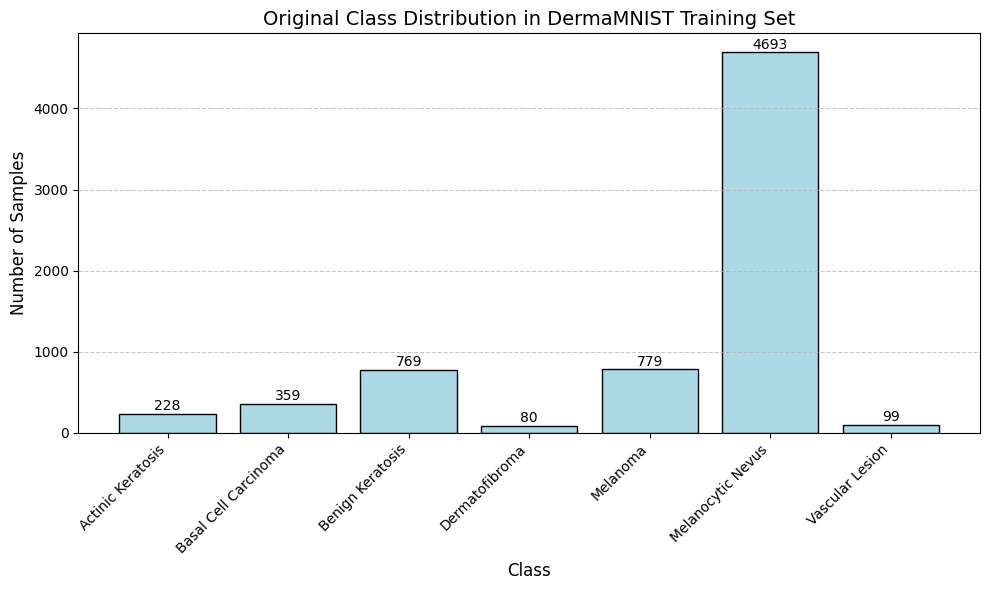

In [32]:
# Plot original training class distribution
unique, counts = np.unique(y_train, return_counts=True)
support_orig = counts[np.argsort(unique)]
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, support_orig, color='lightblue', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}',
             ha='center', va='bottom', fontsize=10)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Original Class Distribution in DermaMNIST Training Set', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('original_class_distribution.png')
# plt.close()

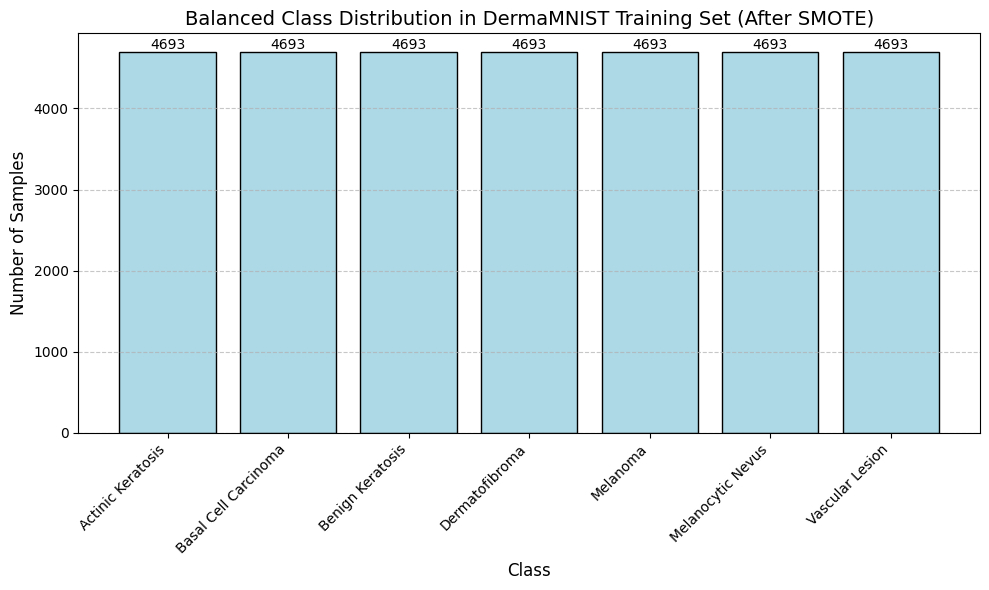

In [33]:
# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Plot balanced training class distribution
unique, counts = np.unique(y_train_balanced, return_counts=True)
support_balanced = counts[np.argsort(unique)]
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, support_balanced, color='lightblue', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}',
             ha='center', va='bottom', fontsize=10)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Balanced Class Distribution in DermaMNIST Training Set (After SMOTE)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('balanced_class_distribution.png')
# plt.close()

In [34]:
# Train Logistic Regression with class weights
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, class_weight='balanced')
model.fit(X_train_balanced, y_train_balanced)


LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

In [35]:
# Evaluate on validation set
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=classes))


Validation Accuracy: 0.5145
Validation Classification Report:
                      precision    recall  f1-score   support

   Actinic Keratosis       0.14      0.30      0.19        33
Basal Cell Carcinoma       0.27      0.42      0.33        52
    Benign Keratosis       0.28      0.35      0.31       110
      Dermatofibroma       0.04      0.17      0.07        12
            Melanoma       0.23      0.39      0.29       111
   Melanocytic Nevus       0.90      0.59      0.71       671
     Vascular Lesion       0.20      0.57      0.29        14

            accuracy                           0.51      1003
           macro avg       0.29      0.40      0.31      1003
        weighted avg       0.68      0.51      0.57      1003



In [36]:
# Evaluate on test set
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=classes))


Test Accuracy: 0.5377
Test Classification Report:
                      precision    recall  f1-score   support

   Actinic Keratosis       0.15      0.32      0.20        66
Basal Cell Carcinoma       0.28      0.44      0.34       103
    Benign Keratosis       0.33      0.43      0.37       220
      Dermatofibroma       0.06      0.26      0.10        23
            Melanoma       0.22      0.35      0.27       223
   Melanocytic Nevus       0.90      0.61      0.72      1341
     Vascular Lesion       0.31      0.72      0.43        29

            accuracy                           0.54      2005
           macro avg       0.32      0.45      0.35      2005
        weighted avg       0.69      0.54      0.59      2005



# **SVM**

In [37]:
from sklearn.svm import SVC

# Initialize the SVM model
svm_model = SVC(probability=True)

# Train the model
svm_model.fit(X_train, y_train)

# Validate the model
y_val_pred = svm_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_class_report = classification_report(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, svm_model.predict_proba(X_val), multi_class='ovr')

print(f"Validation Accuracy: {val_accuracy}")
print("Validation Confusion Matrix:")
print(val_conf_matrix)
print("Validation Classification Report:")
print(val_class_report)
print(f"Validation ROC-AUC: {val_roc_auc}")


Validation Accuracy: 0.7208374875373879
Validation Confusion Matrix:
[[  2   4   6   0   0  21   0]
 [  2  22   7   0   0  21   0]
 [  0   8  32   0   0  70   0]
 [  2   6   0   0   0   4   0]
 [  0   0   6   0   6  99   0]
 [  0   0  10   0   0 661   0]
 [  1   2   1   0   0  10   0]]
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.06      0.10        33
           1       0.52      0.42      0.47        52
           2       0.52      0.29      0.37       110
           3       0.00      0.00      0.00        12
           4       1.00      0.05      0.10       111
           5       0.75      0.99      0.85       671
           6       0.00      0.00      0.00        14

    accuracy                           0.72      1003
   macro avg       0.44      0.26      0.27      1003
weighted avg       0.70      0.72      0.65      1003

Validation ROC-AUC: 0.9101973108495158


In [38]:
# Test the model
y_test_pred = svm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_class_report = classification_report(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, svm_model.predict_proba(X_test), multi_class='ovr')

print(f"Test Accuracy: {test_accuracy}")
print("Test Confusion Matrix:")
print(test_conf_matrix)
print("Test Classification Report:")
print(test_class_report)
print(f"Test ROC-AUC: {test_roc_auc}")


Test Accuracy: 0.7107231920199502
Test Confusion Matrix:
[[   2   15   12    0    2   35    0]
 [   2   33    9    0    0   59    0]
 [   1    6   68    0    2  143    0]
 [   0    7    2    0    0   14    0]
 [   1    1   26    0    8  187    0]
 [   0    9   16    0    2 1314    0]
 [   1    4    2    0    0   22    0]]
Test Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.03      0.05        66
           1       0.44      0.32      0.37       103
           2       0.50      0.31      0.38       220
           3       0.00      0.00      0.00        23
           4       0.57      0.04      0.07       223
           5       0.74      0.98      0.84      1341
           6       0.00      0.00      0.00        29

    accuracy                           0.71      2005
   macro avg       0.36      0.24      0.25      2005
weighted avg       0.65      0.71      0.63      2005

Test ROC-AUC: 0.8977484676669361


In [39]:
import matplotlib.pyplot as plt
import numpy as np
from medmnist import DermaMNIST, INFO
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [40]:
# Normalize to [0, 1] for scikit-learn
X_train = (X_train + 1) / 2
X_val = (X_val + 1) / 2
X_test = (X_test + 1) / 2

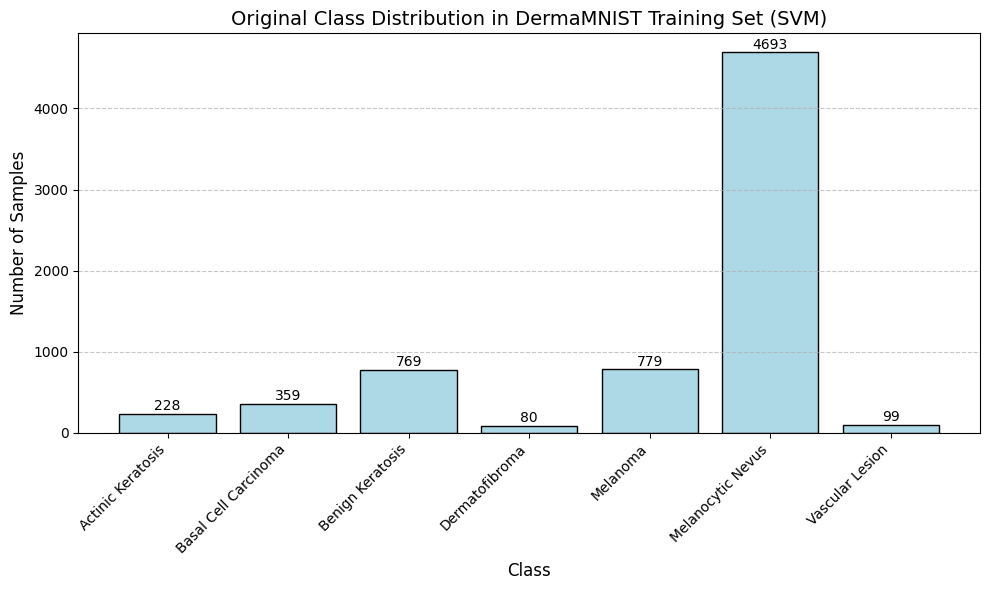

In [41]:
# Plot original training class distribution
unique, counts = np.unique(y_train, return_counts=True)
support_orig = counts[np.argsort(unique)]
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, support_orig, color='lightblue', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}',
             ha='center', va='bottom', fontsize=10)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Original Class Distribution in DermaMNIST Training Set (SVM)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('svm_original_class_distribution.png')
# plt.close()

In [42]:
# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

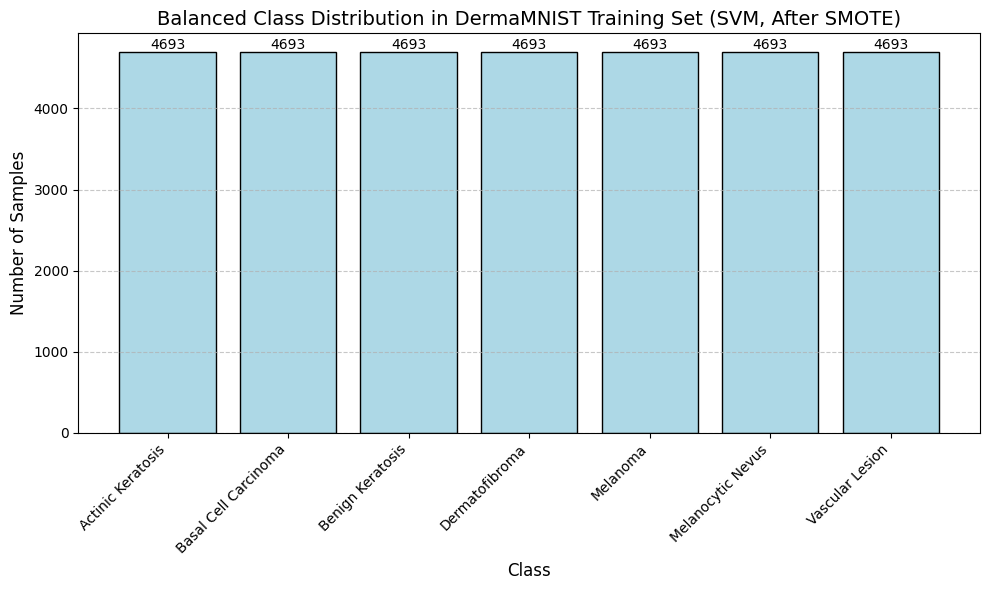

In [43]:
# Plot balanced training class distribution
unique, counts = np.unique(y_train_balanced, return_counts=True)
support_balanced = counts[np.argsort(unique)]
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, support_balanced, color='lightblue', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}',
             ha='center', va='bottom', fontsize=10)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Balanced Class Distribution in DermaMNIST Training Set (SVM, After SMOTE)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('svm_balanced_class_distribution.png')
# plt.close()

In [44]:
# Train SVM with class weights
model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
model.fit(X_train_balanced, y_train_balanced)

SVC(class_weight='balanced', random_state=42)

In [45]:
# Evaluate on validation set
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=classes))


Validation Accuracy: 0.6710
Validation Classification Report:
                      precision    recall  f1-score   support

   Actinic Keratosis       0.36      0.52      0.42        33
Basal Cell Carcinoma       0.43      0.54      0.48        52
    Benign Keratosis       0.45      0.56      0.50       110
      Dermatofibroma       0.33      0.25      0.29        12
            Melanoma       0.35      0.63      0.45       111
   Melanocytic Nevus       0.92      0.72      0.81       671
     Vascular Lesion       0.62      0.57      0.59        14

            accuracy                           0.67      1003
           macro avg       0.49      0.54      0.51      1003
        weighted avg       0.75      0.67      0.70      1003



In [46]:
# Evaluate on test set
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=classes))


Test Accuracy: 0.6544
Test Classification Report:
                      precision    recall  f1-score   support

   Actinic Keratosis       0.32      0.52      0.40        66
Basal Cell Carcinoma       0.38      0.54      0.45       103
    Benign Keratosis       0.46      0.51      0.49       220
      Dermatofibroma       0.22      0.22      0.22        23
            Melanoma       0.31      0.54      0.40       223
   Melanocytic Nevus       0.90      0.72      0.80      1341
     Vascular Lesion       0.70      0.55      0.62        29

            accuracy                           0.65      2005
           macro avg       0.47      0.52      0.48      2005
        weighted avg       0.73      0.65      0.68      2005



# **Gradient Boosting**

In [47]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100)

# Train the model
gb_model.fit(X_train, y_train)

# Validate the model
y_val_pred = gb_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_class_report = classification_report(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, gb_model.predict_proba(X_val), multi_class='ovr')

print(f"Validation Accuracy: {val_accuracy}")
print("Validation Confusion Matrix:")
print(val_conf_matrix)
print("Validation Classification Report:")
print(val_class_report)
print(f"Validation ROC-AUC: {val_roc_auc}")

Validation Accuracy: 0.7128614157527418
Validation Confusion Matrix:
[[  7   7   7   0   2  10   0]
 [  5  21   4   1   4  17   0]
 [  2   9  37   0   6  56   0]
 [  2   5   2   0   0   3   0]
 [  1   0  11   1  18  80   0]
 [  2   3  22   1  13 629   1]
 [  0   0   0   1   0  10   3]]
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.21      0.27        33
           1       0.47      0.40      0.43        52
           2       0.45      0.34      0.38       110
           3       0.00      0.00      0.00        12
           4       0.42      0.16      0.23       111
           5       0.78      0.94      0.85       671
           6       0.75      0.21      0.33        14

    accuracy                           0.71      1003
   macro avg       0.46      0.32      0.36      1003
weighted avg       0.66      0.71      0.67      1003

Validation ROC-AUC: 0.8881690978188524


In [48]:
# Test the model
y_test_pred = gb_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_class_report = classification_report(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, gb_model.predict_proba(X_test), multi_class='ovr')

print(f"Test Accuracy: {test_accuracy}")
print("Test Confusion Matrix:")
print(test_conf_matrix)
print("Test Classification Report:")
print(test_class_report)
print(f"Test ROC-AUC: {test_roc_auc}")


Test Accuracy: 0.7172069825436409
Test Confusion Matrix:
[[  13   13   10    1    3   25    1]
 [   4   41   16    3    1   37    1]
 [   6    7   84    0   10  113    0]
 [   1    8    1    0    1   12    0]
 [   2    3   27    2   37  149    3]
 [   7   15   26    3   24 1260    6]
 [   1    3    3    0    2   17    3]]
Test Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.20      0.26        66
           1       0.46      0.40      0.42       103
           2       0.50      0.38      0.43       220
           3       0.00      0.00      0.00        23
           4       0.47      0.17      0.25       223
           5       0.78      0.94      0.85      1341
           6       0.21      0.10      0.14        29

    accuracy                           0.72      2005
   macro avg       0.40      0.31      0.34      2005
weighted avg       0.67      0.72      0.68      2005

Test ROC-AUC: 0.8842227784094489


# **Convoluted Neural Network**

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from medmnist import DermaMNIST
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Define a simple CNN model
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [50]:
# Initialize the CNN model
model = CNN(in_channels=3, num_classes=7)  # Assuming 3 channels (RGB) and 7 classes

# Data preprocessing and augmentation
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the data with transformations
train_dataset = DermaMNIST(split="train", transform=data_transform, download=True)
test_dataset = DermaMNIST(split="test", transform=data_transform, download=True)
val_dataset = DermaMNIST(split="val", transform=data_transform, download=True)

In [51]:
# Encapsulate data into dataloader form
BATCH_SIZE = 128
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [52]:
# Training the model
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        targets = targets.squeeze().long()  # Ensure targets are the correct shape and type
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {running_loss/len(train_loader)}")



Epoch [1/10], Loss: 6.121001108126207
Epoch [2/10], Loss: 1.046554784341292
Epoch [3/10], Loss: 0.9449181903492321
Epoch [4/10], Loss: 0.7843414360826666
Epoch [5/10], Loss: 0.76264793547717
Epoch [6/10], Loss: 0.7111828988248652
Epoch [7/10], Loss: 0.6619593820788644
Epoch [8/10], Loss: 0.6085017773238095
Epoch [9/10], Loss: 0.5761250598864122
Epoch [10/10], Loss: 0.5474343299865723


In [53]:
# Validate the model
model.eval()
val_correct = 0
val_total = 0
with torch.no_grad():
    for inputs, targets in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        val_total += targets.size(0)
        val_correct += (predicted == targets).sum().item()

val_accuracy = val_correct / val_total
print(f"Validation Accuracy: {val_accuracy}")



Validation Accuracy: 68.79661016949153


In [54]:
# Test the model
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += targets.size(0)
        test_correct += (predicted == targets).sum().item()

test_accuracy = test_correct / test_total
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 70.4354114713217


In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Convert predictions and targets to numpy arrays for metric calculations
def get_predictions_and_targets(loader, model):
    all_preds = []
    all_targets = []
    all_probs = []
    model.eval()
    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_targets), np.array(all_probs)

In [56]:
# Get predictions, targets, and probabilities for validation and test sets
val_preds, val_targets, val_probs = get_predictions_and_targets(val_loader, model)
test_preds, test_targets, test_probs = get_predictions_and_targets(test_loader, model)

In [57]:
# Calculate metrics for validation set
val_precision = precision_score(val_targets, val_preds, average='weighted')
val_recall = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
val_roc_auc = roc_auc_score(val_targets, val_probs, multi_class='ovr')


In [58]:
print(f"Validation Precision: {val_precision}")
print(f"Validation Recall: {val_recall}")
print(f"Validation F1 Score: {val_f1}")
print(f"Validation ROC-AUC: {val_roc_auc}")



Validation Precision: 0.685823463944765
Validation Recall: 0.7168494516450648
Validation F1 Score: 0.6832388926927814
Validation ROC-AUC: 0.89169979362843


In [59]:
# Calculate metrics for test set
test_precision = precision_score(test_targets, test_preds, average='weighted')
test_recall = recall_score(test_targets, test_preds, average='weighted')
test_f1 = f1_score(test_targets, test_preds, average='weighted')
test_roc_auc = roc_auc_score(test_targets, test_probs, multi_class='ovr')


In [60]:

print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1 Score: {test_f1}")
print(f"Test ROC-AUC: {test_roc_auc}")

Test Precision: 0.6792691997717389
Test Recall: 0.7167082294264339
Test F1 Score: 0.677542897536138
Test ROC-AUC: 0.8820582555867732


Five fold cross validation


In [67]:
import matplotlib.pyplot as plt
import numpy as np
from medmnist import DermaMNIST, INFO
from torchvision import transforms
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, KFold
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Combine train and validation for cross-validation
combined_dataset = ConcatDataset([train_dataset, val_dataset])
test_loader = DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

# Extract data for scikit-learn models
def extract_data(dataset_or_loader):
    X, y = [], []
    if isinstance(dataset_or_loader, DataLoader):
        loader = dataset_or_loader
    else:
        loader = DataLoader(dataset_or_loader, batch_size=BATCH_SIZE, shuffle=False)
    for images, labels in loader:
        images = images.numpy().reshape(images.shape[0], -1)  # Flatten: (batch_size, 28*28*3)
        labels = labels.numpy().ravel()  # Shape: (batch_size,)
        X.append(images)
        y.append(labels)
    X = np.concatenate(X)
    y = np.concatenate(y)
    return X, y

# Extract combined and test data
print("Extracting combined training+validation data...")
X_combined, y_combined = extract_data(combined_dataset)
print(f"Combined data shape: X_combined={X_combined.shape}, y_combined={y_combined.shape}")

print("Extracting test data...")
X_test, y_test = extract_data(test_loader)
print(f"Test data shape: X_test={X_test.shape}, y_test={y_test.shape}")

# Normalize to [0, 1] for scikit-learn
X_combined = (X_combined + 1) / 2
X_test = (X_test + 1) / 2

Extracting combined training+validation data...


In [61]:
# Perform 5-fold cross-validation and test evaluation
models = {
    'Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, class_weight='balanced'),
    'SVM': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}
results = {'Model': [], 'Test Accuracy': [], 'CV Mean Accuracy': [], 'CV Std Accuracy': []}



In [68]:
# Scikit-learn models
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_combined, y_combined, cv=kf, scoring='accuracy')
    # Train on full combined data and test
    if name == 'Gradient Boosting':
        # Compute sample weights for Gradient Boosting
        unique_classes, counts = np.unique(y_combined, return_counts=True)
        class_weights = {i: 1.0 / count for i, count in zip(unique_classes, counts)}
        sample_weights = np.array([class_weights[y] for y in y_combined])
        model.fit(X_combined, y_combined, sample_weight=sample_weights)
    else:
        model.fit(X_combined, y_combined)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results['Model'].append(name)
    results['Test Accuracy'].append(test_acc)
    results['CV Mean Accuracy'].append(cv_scores.mean())
    results['CV Std Accuracy'].append(cv_scores.std())

NameError: name 'X_combined' is not defined

In [ ]:
# CNN cross-validation
cnn_cv_scores = []
for train_idx, val_idx in kf.split(X_combined):
    # Create subsets
    train_subset = Subset(combined_dataset, train_idx)
    val_subset = Subset(combined_dataset, val_idx)
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

    # Initialize CNN
    cnn_model = SimpleCNN(n_classes).to(DEVICE)
    # Compute class weights for CNN
    unique_classes, counts = np.unique(y_combined[train_idx], return_counts=True)
    class_weights = torch.tensor([1.0 / count for count in counts], dtype=torch.float).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

    # Train
    train_cnn(cnn_model, train_loader, criterion, optimizer, EPOCHS)
    # Evaluate
    val_acc = evaluate_cnn(cnn_model, val_loader)
    cnn_cv_scores.append(val_acc)

In [ ]:
# Train CNN on full combined data and test
full_loader = DataLoader(combined_dataset, batch_size=BATCH_SIZE, shuffle=True)
cnn_model = SimpleCNN(n_classes).to(DEVICE)
unique_classes, counts = np.unique(y_combined, return_counts=True)
class_weights = torch.tensor([1.0 / count for count in counts], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
train_cnn(cnn_model, full_loader, criterion, optimizer, EPOCHS)
test_acc = evaluate_cnn(cnn_model, test_loader)

results['Model'].append('CNN')
results['Test Accuracy'].append(test_acc)
results['CV Mean Accuracy'].append(np.mean(cnn_cv_scores))
results['CV Std Accuracy'].append(np.std(cnn_cv_scores))

In [ ]:
# Print results
print("\nModel Comparison:")
print(f"{'Model':<20} {'Test Accuracy':<15} {'CV Mean Accuracy':<20} {'CV Std Accuracy':<15}")
for i in range(len(results['Model'])):
    print(f"{results['Model'][i]:<20} {results['Test Accuracy'][i]:.4f} {'':<8} {results['CV Mean Accuracy'][i]:.4f} {'':<8} {results['CV Std Accuracy'][i]:.4f}")

In [ ]:
# Plot comparison
plt.figure(figsize=(10, 6))
x = np.arange(len(results['Model']))
bar_width = 0.35
plt.bar(x - bar_width/2, results['Test Accuracy'], bar_width, label='Test Accuracy', color='skyblue')
plt.bar(x + bar_width/2, results['CV Mean Accuracy'], bar_width, yerr=results['CV Std Accuracy'],
        label='CV Mean Accuracy', color='lightcoral', capsize=5)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Test Accuracy vs. 5-Fold Cross-Validation Accuracy on DermaMNIST', fontsize=14)
plt.xticks(x, results['Model'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('model_comparison.png')
# plt.close()